In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("car data.csv")

# Show first 5 rows
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [2]:
# Check dataset information

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (301, 9)

Column Names:
Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='str')

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [3]:
# Basic statistical summary

print("Statistical Summary:")
print(df.describe())

Statistical Summary:
              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.900000       1.200000   15000.000000    0.000000
50%    2014.000000       3.600000       6.400000   32000.000000    0.000000
75%    2016.000000       6.000000       9.900000   48767.000000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000


In [4]:
# Prepare data for machine learning

X = df.drop(["Car_Name", "Selling_Price"], axis=1)
y = df["Selling_Price"]

# Convert categorical columns into numerical values
X = pd.get_dummies(X, drop_first=True)

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.head())

Features:
Index(['Year', 'Present_Price', 'Driven_kms', 'Owner', 'Fuel_Type_Diesel',
       'Fuel_Type_Petrol', 'Selling_type_Individual', 'Transmission_Manual'],
      dtype='str')

Target:
0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64


In [5]:
# Split data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (240, 8)
Testing data: (61, 8)


In [6]:
# Train Linear Regression Model

from sklearn.linear_model import LinearRegression

model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

print("Model training completed successfully!")

Model training completed successfully!


In [7]:
# Evaluate the model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation:")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)
print("Accuracy:", r2 * 100, "%")

Model Evaluation:
Mean Absolute Error (MAE): 1.216374019332988
Mean Squared Error (MSE): 3.481349830510787
Root Mean Squared Error (RMSE): 1.8658375680939612
R² Score: 0.8488707839193601
Accuracy: 84.88707839193602 %


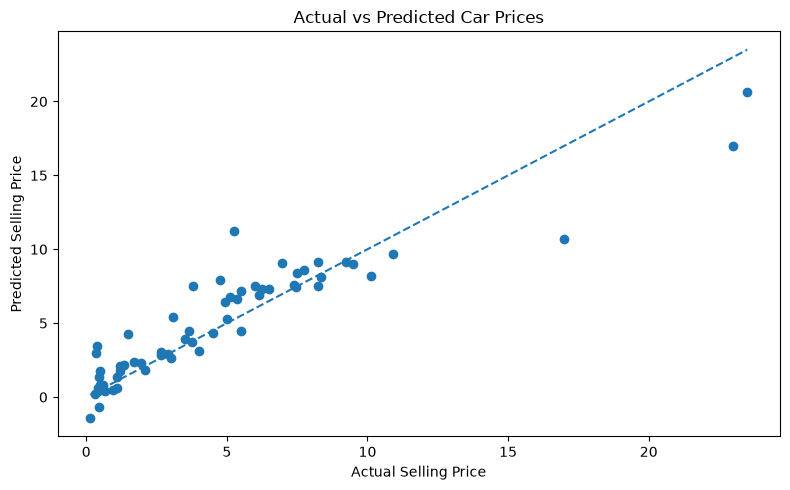

In [8]:
# Actual vs Predicted Car Prices

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.tight_layout()
plt.show()

In [9]:
# Final Conclusion

print("Task 3: Car Price Prediction - Conclusion")
print()
print("1. A Linear Regression model was trained to predict car selling prices.")
print("2. The model achieved an R² Score of approximately 0.849.")
print("3. The model explains about 84.9% of the variation in car selling prices.")
print("4. Present Price, Year, Driven Kilometers and other car features were used for prediction.")
print("5. The Actual vs Predicted graph shows that most predictions are reasonably close to actual prices.")
print("6. The model can be useful for estimating used-car selling prices.")

Task 3: Car Price Prediction - Conclusion

1. A Linear Regression model was trained to predict car selling prices.
2. The model achieved an R² Score of approximately 0.849.
3. The model explains about 84.9% of the variation in car selling prices.
4. Present Price, Year, Driven Kilometers and other car features were used for prediction.
5. The Actual vs Predicted graph shows that most predictions are reasonably close to actual prices.
6. The model can be useful for estimating used-car selling prices.
